# Task 1. Sports Event Type Classification from Frames

The goal of this work is to build a convolutional neural network that predicts the sport type from a single video frame.

The data source is Sports-1M. The original `train_partition.txt` and `test_partition.txt` files contain YouTube URLs and numeric class labels. Available videos are downloaded, frames are extracted, resized to `128x128x3`, and saved into class folders.


## 1. Problem Statement

This is a multiclass image classification task.

Model input: an RGB image with shape `128x128x3`.

Model output: class probabilities for sport categories.

Evaluation metrics:

- `Accuracy`;
- `Precision`;
- `Recall`;
- `F1-score`.

Main idea: a CNN can learn visual patterns such as the field, court, water, snow, players' uniforms, balls, and other sport-specific objects.


In [3]:
# !pip install opencv-python

In [4]:
from pathlib import Path
import json
import random
from dataclasses import dataclass
from typing import Iterable

import cv2
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

PROJECT_DIR = Path.cwd()
DATA_DIR = PROJECT_DIR / "data"
TRAIN_DIR = DATA_DIR / "frames" / "train"
TEST_DIR = DATA_DIR / "frames" / "test"
RUN_DIR = PROJECT_DIR / "runs" / "cnn"
IMAGE_SIZE = 128
SEED = 42

random.seed(SEED)
np.random.seed(SEED)


## 2. Class Selection and Sports-1M Metadata Parsing

Some Sports-1M rows contain multiple labels. For a standard multiclass classifier, a row is used only when exactly one of the selected target classes is present. This avoids ambiguous labels.

The selected class mapping is stored in `configs/selected_sports.json`. The project uses `association football` as the Sports-1M label for the output class `football`, and `swimming (sport)` for the output class `swimming`.


In [5]:
labels = [line.strip() for line in Path("labels.txt").read_text(encoding="utf-8").splitlines() if line.strip()]
label_to_id = {label: idx for idx, label in enumerate(labels)}

selected_config = json.loads(Path("configs/selected_sports.json").read_text(encoding="utf-8"))
selected_ids = {
    label_to_id[sports1m_label]: output_name
    for output_name, sports1m_label in selected_config.items()
    if sports1m_label in label_to_id
}

pd.DataFrame(
    [
        {"output_class": class_name, "sports1m_label": labels[label_id], "label_id": label_id}
        for label_id, class_name in selected_ids.items()
    ]
).sort_values("output_class")


,output_class,sports1m_label,label_id
9,baseball,baseball,375
8,basketball,basketball,367
0,boxing,boxing,1
1,cycling,cycling,7
7,football,association football,356
2,gymnastics,gymnastics,25
6,hockey,hockey,337
4,skiing,skiing,77
5,swimming,swimming (sport),87
3,tennis,tennis,54


In [6]:
def parse_partition(partition_path: Path, selected: dict[int, str]) -> pd.DataFrame:
    rows = []
    for line in partition_path.read_text(encoding="utf-8").splitlines():
        parts = line.strip().split()
        if len(parts) != 2:
            continue

        url, label_part = parts
        try:
            label_ids = [int(item) for item in label_part.split(",")]
        except ValueError:
            continue

        hits = [label_id for label_id in label_ids if label_id in selected]
        if len(hits) != 1:
            continue

        rows.append({"url": url, "class_name": selected[hits[0]], "label_id": hits[0]})

    return pd.DataFrame(rows)

train_meta = parse_partition(Path("train_partition.txt"), selected_ids)
test_meta = parse_partition(Path("test_partition.txt"), selected_ids)

pd.concat(
    [
        train_meta.groupby("class_name").size().rename("train_urls"),
        test_meta.groupby("class_name").size().rename("test_urls"),
    ],
    axis=1,
).fillna(0).astype(int)

,train_urls,test_urls
class_name,,
baseball,1615,1046
basketball,1930,580
boxing,1380,1266
cycling,2155,519
football,1933,484
gymnastics,2187,471
hockey,2048,349
skiing,2174,492
swimming,2171,500


## 3. Video Parsing and Frame Extraction

The full parser is implemented in `scripts/prepare_frames.py`. The main pipeline is shown below.

Pipeline:

1. Read `labels.txt` and a Sports-1M partition file.
2. Keep only the selected target classes.
3. Download available YouTube videos with `yt-dlp`.
4. Sample several frames uniformly across each video.
5. Apply center crop and resize to `128x128`.
6. Save frames into class folders.
7. Write successful and failed attempts to `data/logs`.

Private, removed, or unavailable YouTube videos are skipped. This is expected because Sports-1M is an old dataset and many original links are no longer available.


In [7]:
import yt_dlp

@dataclass(frozen=True)
class VideoRow:
    url: str
    class_name: str


def safe_video_id(url: str) -> str:
    if "v=" in url:
        return url.split("v=", 1)[1].split("&", 1)[0]
    return "".join(char if char.isalnum() else "_" for char in url)[-32:]


def frame_indices(total_frames: int, needed: int, start_ratio: float = 0.05, end_ratio: float = 0.95) -> Iterable[int]:
    start = int(total_frames * start_ratio)
    end = int(total_frames * end_ratio)
    if end <= start:
        start, end = 0, total_frames - 1

    if needed <= 1:
        yield max(start, 0)
        return

    for idx in range(needed):
        yield int(round(start + (end - start) * idx / (needed - 1)))


def center_crop_resize(frame: np.ndarray, size: int = 128) -> np.ndarray:
    height, width = frame.shape[:2]
    side = min(height, width)
    y0 = max((height - side) // 2, 0)
    x0 = max((width - side) // 2, 0)
    cropped = frame[y0:y0 + side, x0:x0 + side]
    return cv2.resize(cropped, (size, size), interpolation=cv2.INTER_AREA)


def extract_frames(video_path: Path, output_dir: Path, class_name: str, video_id: str, needed: int = 12) -> int:
    output_dir.mkdir(parents=True, exist_ok=True)
    capture = cv2.VideoCapture(str(video_path))
    if not capture.isOpened():
        return 0

    total_frames = int(capture.get(cv2.CAP_PROP_FRAME_COUNT))
    written = 0

    for source_idx in frame_indices(total_frames, needed):
        capture.set(cv2.CAP_PROP_POS_FRAMES, source_idx)
        ok, frame = capture.read()
        if not ok or frame is None:
            continue

        resized = center_crop_resize(frame, IMAGE_SIZE)
        output_path = output_dir / f"{class_name}_{video_id}_{source_idx:07d}.jpg"
        written += int(cv2.imwrite(str(output_path), resized, [cv2.IMWRITE_JPEG_QUALITY, 92]))

    capture.release()
    return written


In [8]:
# Example parser launch. It is commented out to avoid starting a long download process.

# !uv run python scripts/prepare_frames.py #   --partition train_partition.txt #   --output data/frames/train #   --target-per-class 3000 #   --max-frames-per-video 30

# !uv run python scripts/prepare_frames.py #   --partition test_partition.txt #   --output data/frames/test #   --target-per-class 1000 #   --max-frames-per-video 20


## 4. Dataset Preparation and Loading

After manual filtering, frames are stored in `data/frames/train` and `data/frames/test`. The folder name is used as the class label.

In the final filtered dataset, 9 classes remain. The `hockey` class was removed during manual filtering.


Actual image counts after manual filtering:

| Class | Train | Test |
|---|---:|---:|
| baseball | 2701 | 696 |
| basketball | 1701 | 424 |
| boxing | 1649 | 221 |
| cycling | 1601 | 469 |
| football | 1645 | 552 |
| gymnastics | 2546 | 847 |
| skiing | 1887 | 591 |
| swimming | 1664 | 451 |
| tennis | 1066 | 302 |


In [10]:
def count_images(root: Path) -> pd.Series:
    counts = {}
    if not root.exists():
        return pd.Series(dtype=int)
    for class_dir in sorted(path for path in root.iterdir() if path.is_dir()):
        counts[class_dir.name] = sum(
            1 for path in class_dir.rglob("*")
            if path.suffix.lower() in {".jpg", ".jpeg", ".png"}
        )
    return pd.Series(counts, dtype=int)

counts_df = pd.concat(
    [count_images(TRAIN_DIR).rename("train"), count_images(TEST_DIR).rename("test")],
    axis=1,
).fillna(0).astype(int)

counts_df


,train,test
baseball,2701,696
basketball,1701,424
boxing,1649,221
cycling,1601,469
football,1645,552
gymnastics,2546,847
skiing,1887,591
swimming,1664,451
tennis,1066,302


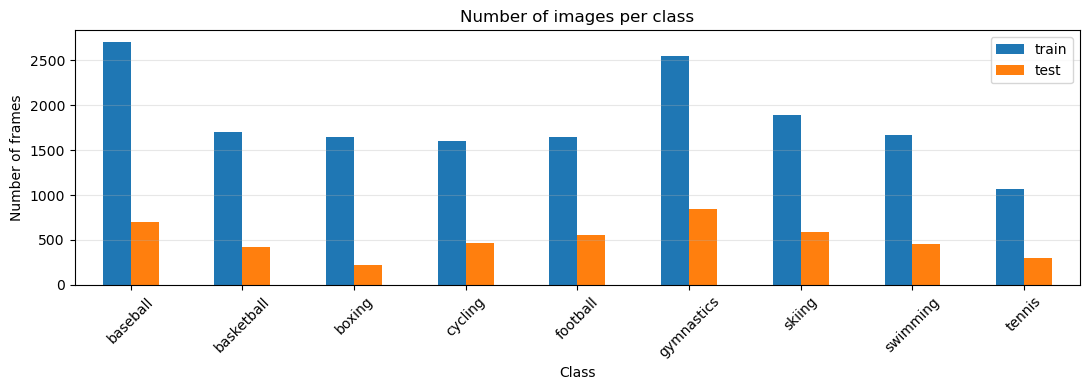

In [11]:
ax = counts_df.plot(kind="bar", figsize=(11, 4), rot=45)
ax.set_title("Number of images per class")
ax.set_xlabel("Class")
ax.set_ylabel("Number of frames")
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()


## 5. Data Augmentation

Since the training set became smaller after manual filtering, augmentation is used to improve generalization. Augmentations are applied on the fly during training and do not create extra files on disk.

Training augmentations:

- random crop to `128x128`;
- horizontal flip;
- small rotation;
- brightness, contrast, saturation, and hue jitter;
- small translation and scaling;
- RGB normalization.

Validation and test images use only resize and normalization.


In [14]:
# !pip install torch

In [17]:
# !pip install torchvision

In [18]:
import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, Subset
from sklearn.model_selection import train_test_split

normalize = transforms.Normalize(
    mean=[0.485, 0.456, 0.406],
    std=[0.229, 0.224, 0.225],
)

train_transforms = transforms.Compose([
    transforms.Resize((IMAGE_SIZE + 24, IMAGE_SIZE + 24)),
    transforms.RandomResizedCrop(IMAGE_SIZE, scale=(0.70, 1.0), ratio=(0.85, 1.15)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=12),
    transforms.ColorJitter(brightness=0.20, contrast=0.20, saturation=0.20, hue=0.03),
    transforms.RandomAffine(degrees=0, translate=(0.08, 0.08), scale=(0.90, 1.10)),
    transforms.ToTensor(),
    normalize,
])

eval_transforms = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    normalize,
])


In [19]:
train_aug_dataset = datasets.ImageFolder(TRAIN_DIR, transform=train_transforms)
train_eval_dataset = datasets.ImageFolder(TRAIN_DIR, transform=eval_transforms)
test_dataset = datasets.ImageFolder(TEST_DIR, transform=eval_transforms)

classes = train_aug_dataset.classes
num_classes = len(classes)

labels_np = np.array(train_aug_dataset.targets)
indices = np.arange(len(labels_np))
train_idx, val_idx = train_test_split(
    indices,
    test_size=0.15,
    random_state=SEED,
    stratify=labels_np,
)

batch_size = 64
train_loader = DataLoader(Subset(train_aug_dataset, train_idx), batch_size=batch_size, shuffle=True, num_workers=0)
val_loader = DataLoader(Subset(train_eval_dataset, val_idx), batch_size=batch_size, shuffle=False, num_workers=0)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=0)

num_classes, classes


(9,
 ['baseball',
  'basketball',
  'boxing',
  'cycling',
  'football',
  'gymnastics',
  'skiing',
  'swimming',
  'tennis'])

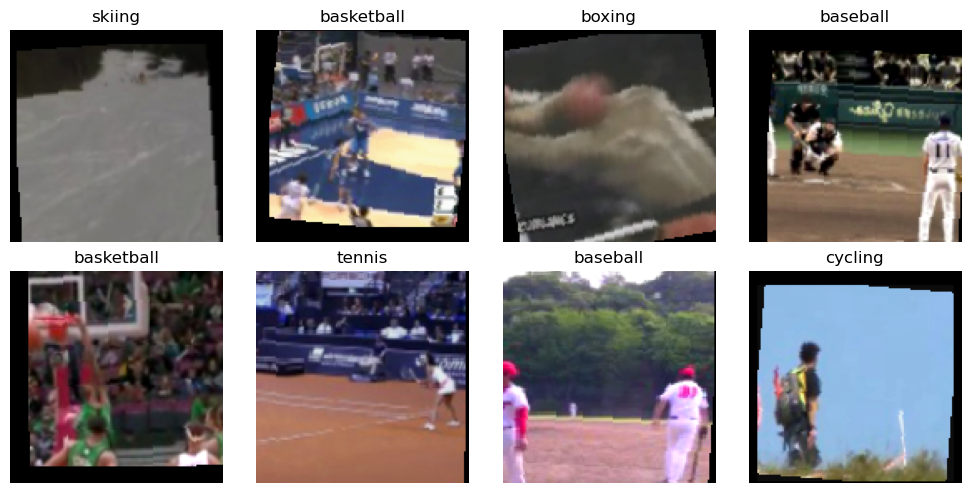

In [20]:
def denormalize(tensor: torch.Tensor) -> torch.Tensor:
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
    std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
    return torch.clamp(tensor.cpu() * std + mean, 0, 1)

images, labels_batch = next(iter(train_loader))
fig, axes = plt.subplots(2, 4, figsize=(10, 5))
for ax, image, label in zip(axes.ravel(), images[:8], labels_batch[:8]):
    ax.imshow(denormalize(image).permute(1, 2, 0))
    ax.set_title(classes[int(label)])
    ax.axis("off")
plt.tight_layout()
plt.show()


## 6. CNN Architecture

The model consists of several convolutional blocks. Each block contains `Conv2d`, `BatchNorm2d`, and `ReLU`. Pooling layers reduce spatial resolution. The final part uses `AdaptiveAvgPool2d`, a fully connected classifier, and `Dropout` regularization.

Loss function: `CrossEntropyLoss` with class weights, because the filtered dataset is imbalanced.

Optimizer: `AdamW`.


In [21]:
from torch import nn

class SportsCNN(nn.Module):
    def __init__(self, num_classes: int, dropout: float = 0.35) -> None:
        super().__init__()
        self.features = nn.Sequential(
            self._block(3, 32),
            nn.MaxPool2d(2),
            self._block(32, 64),
            nn.MaxPool2d(2),
            self._block(64, 128),
            nn.MaxPool2d(2),
            self._block(128, 256),
            nn.MaxPool2d(2),
            nn.AdaptiveAvgPool2d((1, 1)),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(dropout),
            nn.Linear(256, 128),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout),
            nn.Linear(128, num_classes),
        )

    @staticmethod
    def _block(in_channels: int, out_channels: int) -> nn.Sequential:
        return nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.classifier(self.features(x))

model = SportsCNN(num_classes=num_classes)
model


SportsCNN(
  (features): Sequential(
    (0): Sequential(
      (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (2): ReLU(inplace=True)
      (3): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (4): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (5): ReLU(inplace=True)
    )
    (1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (2): Sequential(
      (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (2): ReLU(inplace=True)
      (3): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, trac

## 7. Model Training

The full training code is stored in `scripts/train_cnn.py`. The command below was used to train the model.

During training, the best checkpoint is selected by validation accuracy. After training, the best model is evaluated on the test set.


In [22]:
# Training command. It is commented out to avoid accidentally restarting training.

# !uv run python scripts/train_cnn.py #   --train-dir data/frames/train #   --test-dir data/frames/test #   --output-dir runs/cnn #   --epochs 20 #   --batch-size 64


,epoch,train_loss,train_acc,val_loss,val_acc
15,16,0.880630,0.709360,0.875719,0.718813
16,17,0.873488,0.710422,0.803578,0.725231
17,18,0.807238,0.736194,0.770035,0.747694
18,19,0.795775,0.740867,0.799688,0.738869
19,20,0.780173,0.744123,0.883041,0.724027


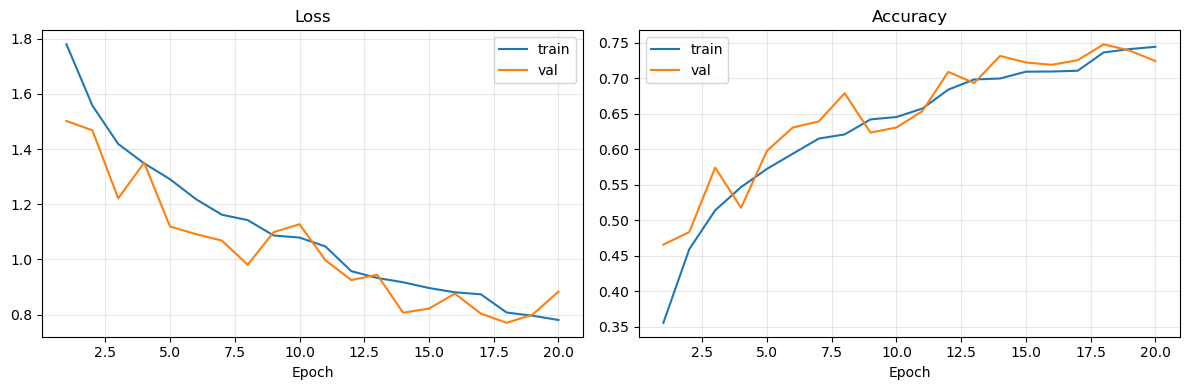

In [23]:
history_path = RUN_DIR / "history.json"
if history_path.exists():
    history_df = pd.read_json(history_path)
    display(history_df.tail())

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    axes[0].plot(history_df["epoch"], history_df["train_loss"], label="train")
    axes[0].plot(history_df["epoch"], history_df["val_loss"], label="val")
    axes[0].set_title("Loss")
    axes[0].set_xlabel("Epoch")
    axes[0].grid(alpha=0.3)
    axes[0].legend()

    axes[1].plot(history_df["epoch"], history_df["train_acc"], label="train")
    axes[1].plot(history_df["epoch"], history_df["val_acc"], label="val")
    axes[1].set_title("Accuracy")
    axes[1].set_xlabel("Epoch")
    axes[1].grid(alpha=0.3)
    axes[1].legend()

    plt.tight_layout()
    plt.show()
else:
    print("history.json was not found. Run training first.")


## 8. Results

Final metrics on the test set:

| Metric | Value |
|---|---:|
| `accuracy` | 0.7678 |
| `weighted_precision` | 0.7832 |
| `weighted_recall` | 0.7678 |
| `weighted_f1` | 0.7713 |
| `macro_precision` | 0.7532 |
| `macro_recall` | 0.7733 |
| `macro_f1` | 0.7570 |
| `best_val_acc` | 0.7477 |
| `best_epoch` | 18 |


In [24]:
metrics_path = RUN_DIR / "metrics.json"
if metrics_path.exists():
    metrics = json.loads(metrics_path.read_text(encoding="utf-8"))
    pd.DataFrame(
        [
            {"metric": key, "value": value}
            for key, value in metrics.items()
            if isinstance(value, (int, float))
        ]
    )
else:
    print("metrics.json was not found.")


In [25]:
report_path = RUN_DIR / "classification_report.txt"
if report_path.exists():
    print(report_path.read_text(encoding="utf-8"))
else:
    print("classification_report.txt was not found.")


              precision    recall  f1-score   support

    baseball       0.85      0.85      0.85       696
  basketball       0.71      0.69      0.70       424
      boxing       0.49      0.77      0.60       254
     cycling       0.66      0.67      0.67       469
    football       0.79      0.73      0.76       552
  gymnastics       0.80      0.68      0.73       851
      skiing       0.92      0.83      0.87       591
    swimming       0.93      0.89      0.91       451
      tennis       0.63      0.85      0.72       302

    accuracy                           0.77      4590
   macro avg       0.75      0.77      0.76      4590
weighted avg       0.78      0.77      0.77      4590



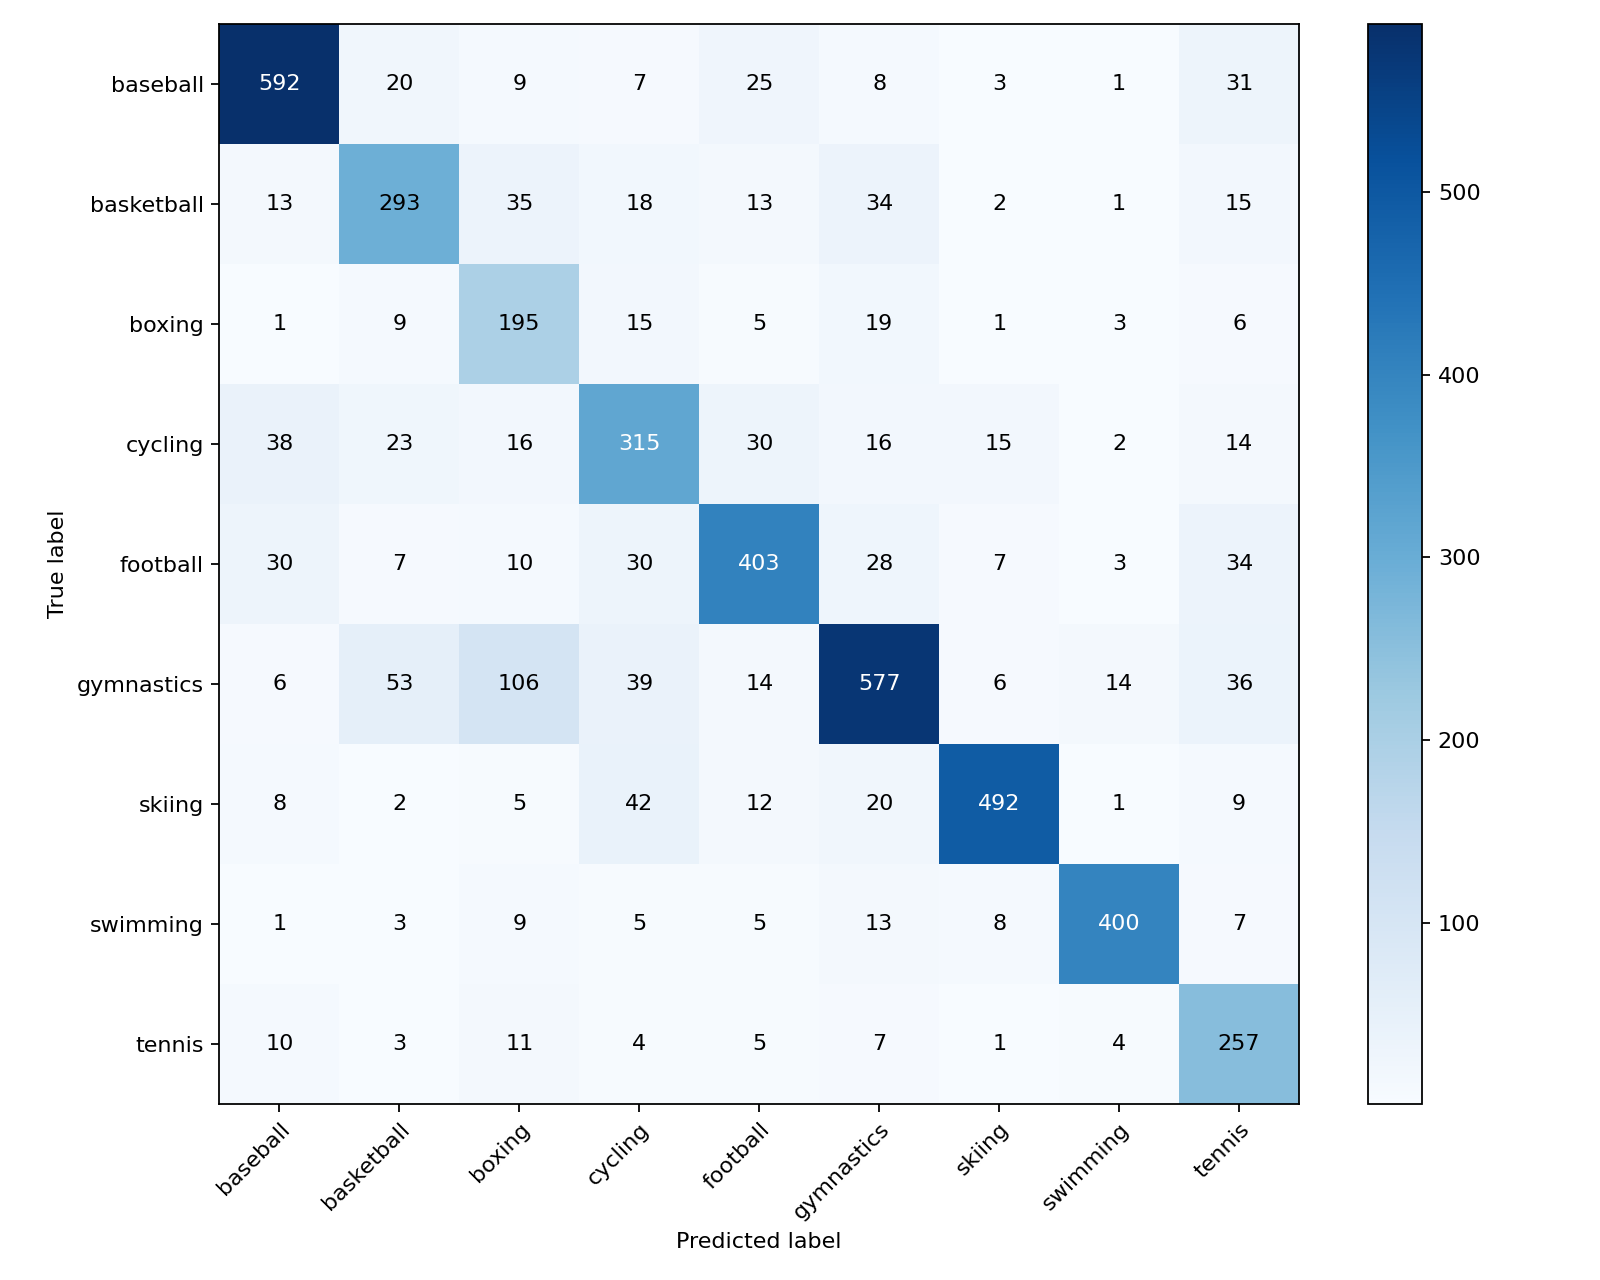

In [26]:
from IPython.display import Image, display

cm_path = RUN_DIR / "confusion_matrix.png"
if cm_path.exists():
    display(Image(filename=str(cm_path)))
else:
    print("confusion_matrix.png was not found.")


## 9. Conclusion

In this work, a frame dataset for sports event classification was prepared and a CNN model was trained.

Completed steps:

- parsed Sports-1M metadata;
- selected target sport classes;
- implemented video downloading and `128x128x3` frame extraction;
- organized frames into class folders;
- created train and test datasets after manual filtering;
- applied image augmentations to improve generalization;
- built and trained a convolutional neural network;
- evaluated the model using Accuracy, Precision, Recall, and F1-score.

The trained model achieved acceptable quality for frame-level sport classification. The strongest classes are sports with a distinctive visual environment, such as `swimming`, `skiing`, and `baseball`. More difficult classes are those with visually diverse scenes or overlap with other sports.

Possible improvements:

- collect more high-quality images for weaker classes;
- remove duplicate or nearly identical frames from the same video;
- use transfer learning with a pretrained model such as ResNet or EfficientNet;
- analyze errors using the confusion matrix;
- use short frame sequences instead of single frames.
